# Handwritten Digit Recognition with Neural Networks

## 1. Project Overview

This project uses a neural network built with TensorFlow/Keras to recognize handwritten digits from the MNIST dataset.

The model takes a 28×28 grayscale image as input and predicts one of 10 digit classes (0–9).

### Project Workflow

1. Load and explore the MNIST dataset
2. Preprocess the image data
3. Build a neural network
4. Train the model
5. Evaluate model performance
6. Analyze predictions using a confusion matrix
7. Investigate misclassified images
8. Make individual predictions
9. Save the trained model


## 2. Import Libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.models import Sequential 
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
print(tf.__version__)
print(sns.__version__)

2.21.0
0.13.2


## 3. Load the MNIST Dataset

We're using `tensorflow.keras.datasets.mnist`, a benchmark dataset built into Keras.
Unlike our previous CSV-based projects, this dataset comes pre-split into training
and test sets, and requires no cleaning — it's already curated for ML use.

`load_data()` returns a nested tuple: `(x_train, y_train), (x_test, y_test)`.
We unpack it immediately into four separate variables rather than keeping the nested
structure, since flat variable names are easier to pass into functions and read
throughout the rest of the notebook.

In [2]:
from tensorflow.keras.datasets import mnist
(X_train,y_train),(X_test,y_test) = mnist.load_data()

## 4. Explore the Dataset

### 4.1 Inspect the Shapes

Before doing anything else, we confirm the data loaded as expected. `x_train` should
be a 3D array: (number of images, height, width) — note there's no channel dimension,
since grayscale images only need one value per pixel (unlike RGB, which needs 3).
`y_train` should be 1D: one label per image.

Checking shapes early catches structural bugs (wrong dataset, bad unpacking) before
they cause confusing errors two steps later.

In [3]:
print("X_train Shape : ",X_train.shape)
print("X_test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_train Shape :  (60000, 28, 28)
X_test Shape :  (10000, 28, 28)
y_train Shape :  (60000,)
y_test Shape :  (10000,)


### 4.2 Pixel Value Range

Raw MNIST pixels are `uint8`, ranging 0–255. Confirming this now tells us
normalization is required before feeding data into the network (NNs train
better on small, centered input ranges).

In [4]:
print("Min Pixel Value : ",X_train.min())
print("Max Pixel Value : ",X_train.max())

Min Pixel Value :  0
Max Pixel Value :  255


### 4.3 Class Distribution

Checking how many examples exist per digit (0–9). `np.unique` with
`return_counts=True` gives us both the unique labels and their counts in
one call — faster and cleaner than a manual loop.

In [5]:
labels , counts = np.unique(y_train , return_counts=True)
for label,count in zip(labels,counts):
    print(f"Digit {label} : {count} Samples")

Digit 0 : 5923 Samples
Digit 1 : 6742 Samples
Digit 2 : 5958 Samples
Digit 3 : 6131 Samples
Digit 4 : 5842 Samples
Digit 5 : 5421 Samples
Digit 6 : 5918 Samples
Digit 7 : 6265 Samples
Digit 8 : 5851 Samples
Digit 9 : 5949 Samples


### 4.4 Visual Sanity Check

Plotting a few images with their labels confirms the pixel data actually
matches the labels — catches loading/indexing bugs that shapes alone
wouldn't reveal.

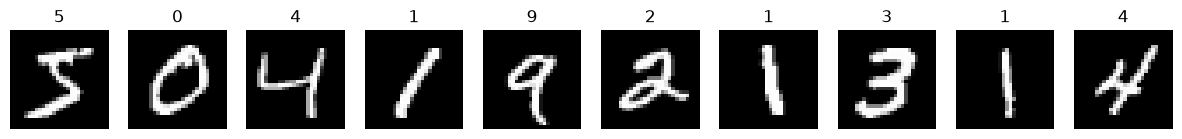

In [6]:
fig , axes = plt.subplots(1,10,figsize=(15,2))
for i,ax in enumerate(axes):
    ax.imshow(X_train[i],cmap='gray')
    ax.set_title(y_train[i])
    ax.axis('off')
plt.show()

## 5. Data Preprocessing

### 5.1 Normalize Pixel Values

Raw pixels range 0–255. Neural networks train faster and more stably on small,
centered inputs, so we scale to 0–1 by dividing by 255.0. This mirrors the
same reasoning as feature scaling in your earlier logistic regression project —
just via division here instead of `StandardScaler`, since pixel values already
share a known, fixed range (unlike arbitrary feature magnitudes).

In [7]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

### 5.2 Check

In [8]:
print("Min Pixel Value : ",X_train.min())
print("Max Pixel Value : ",X_train.max())

Min Pixel Value :  0.0
Max Pixel Value :  1.0


### 5.3 Flatten the Images

Each image is (28, 28) — a 2D grid. A plain feedforward NN's Dense layers expect
1D input per sample, so we flatten each image into a 784-length vector
(28 × 28 = 784). This matches the style of Andrew Ng's Course 2 labs, where
inputs arrive pre-flattened as feature vectors rather than 2D grids.

In [9]:
X_train = X_train.reshape(X_train.shape[0],784)
X_test = X_test.reshape(X_test.shape[0],784)

### 5.4 Preprocessing: Labels

Labels are already integers 0–9 — no encoding needed. We'll keep them as-is
(**sparse** labels) rather than one-hot encoding, and pair this with
`sparse_categorical_crossentropy` as the loss function later. This is the
standard practical choice for multi-class problems: same math as one-hot +
categorical_crossentropy, but skips the memory overhead of one-hot vectors.

## 6. Build the Neural Network

### 6.1 Building the Model Architecture

We'll use `tf.keras.Sequential` — a linear stack of layers.

**Architecture:**
| Layer | Type | Units | Activation | Input shape | Output shape |
|---|---|---|---|---|---|
| Hidden 1 | Dense | 128 | ReLU | (784,) | (128,) |
| Hidden 2 | Dense | 64 | ReLU | (128,) | (64,) |
| Output | Dense | 10 | **linear** | (64,) | (10,) |

*(Shapes shown per-sample; Keras handles the batch dimension automatically.)*

**Add an Explicit Input Layer**

Adding `Input(shape=(784,))` as the first item in the list instead of passing
`input_shape` inside the first `Dense` call. This makes the model's expected
input explicit and separate from the first actual computational layer.

**Why ReLU for hidden layers:** standard default — cheap to compute, avoids
vanishing gradients that sigmoid/tanh suffer from in deeper networks.

**Why the output layer uses `linear` activation, not `softmax`:** this is the
numerically stable pattern taught in Course 2 Week 2. The output layer produces
raw scores (**logits**) instead of probabilities. Softmax is then applied
*inside the loss function* (`from_logits=True`) during compilation rather than
as a layer — this avoids the precision loss that comes from computing softmax
and then log(softmax) as two separate steps. You'll set this up in the compile
step next.

**Each Dense layer** computes `activation(W·x + b)` — weights `W`, bias `b`, and
your chosen activation, same math as your logistic regression project, just
stacked and repeated per layer.

In [10]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128,activation='relu',name='L1'),
    Dense(64,activation='relu',name='L2'),
    Dense(10,name='Output')
])

### 6.2 Compile the Model

Compiling configures *how* the model learns — three things to specify:

**Loss function:** `SparseCategoricalCrossentropy(from_logits=True)`
- "Sparse" because our labels are plain integers (0–9), not one-hot vectors
- `from_logits=True` because our output layer has no activation — it outputs
  raw scores, so the loss function applies softmax internally 

**Optimizer:** `'adam'`
- Adaptive learning rate, works well as a default 

**Metrics:** `['accuracy']`
- Tracked during training for monitoring, not used in the actual gradient updates

In [11]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits=True),
    optimizer = Adam(),
    metrics = ["accuracy"]
)

## 7. Train the Model

`model.fit()` runs the training loop: forward pass → compute loss → backprop →
update weights, repeated per batch, for a set number of passes over the full
dataset (**epochs**).

**Key arguments:**
- `x_train, y_train` — training data and labels
- `epochs` — how many full passes through the training data (start with 10)
- `validation_split=0.1` — holds out 10% of training data to monitor performance
  on unseen data *during* training, so we can catch overfitting as it happens,
  not just at the end
- `batch_size` — how many samples processed before each weight update
  (default 32 is fine to start)

Store the return value — `fit()` returns a **History** object containing the
loss/accuracy per epoch, which we'll use to plot training curves next.

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9250 - loss: 0.2543 - val_accuracy: 0.9688 - val_loss: 0.1080
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9682 - loss: 0.1037 - val_accuracy: 0.9763 - val_loss: 0.0788
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9778 - loss: 0.0716 - val_accuracy: 0.9757 - val_loss: 0.0769
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9832 - loss: 0.0532 - val_accuracy: 0.9795 - val_loss: 0.0717
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9863 - loss: 0.0429 - val_accuracy: 0.9752 - val_loss: 0.0852
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9889 - loss: 0.0343 - val_accuracy: 0.9780 - val_loss: 0.0880
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9913 - loss: 0.0264 - val_accuracy: 0.9752 - val_loss: 0.0911
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9913 - loss: 0.0264 - 

### 7.1 Plot Training Curves

Plotting loss and accuracy per epoch (train vs. validation) reveals how
learning progressed — and gives an early look at overfitting: if training
accuracy keeps climbing while validation accuracy plateaus or drops, the
model is memorizing rather than generalizing. This is the visual precursor
to the bias/variance analysis .

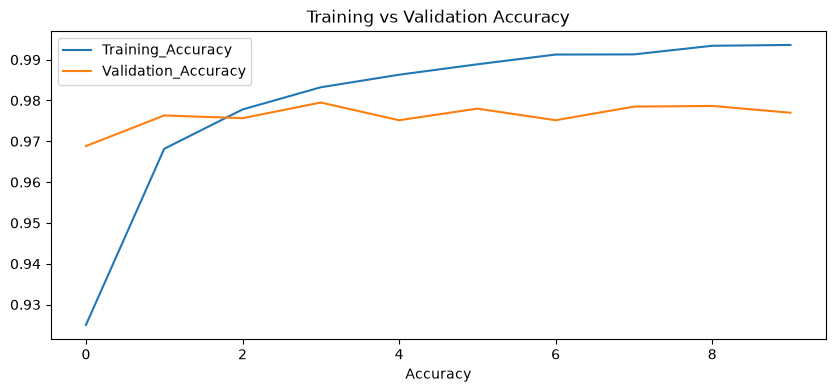

In [13]:
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"],label="Training_Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation_Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

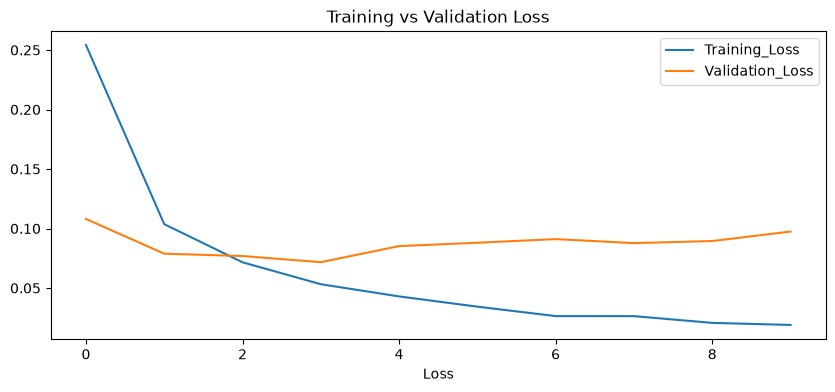

In [14]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"],label="Training_Loss")
plt.plot(history.history["val_loss"],label="Validation_Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## 8. Evaluate on the Test Set

Test data was never seen during training or validation — this is the true,
unbiased measure of how the model generalizes.

In [15]:
test_loss,test_accuracy = model.evaluate(X_test,y_test)
print(f"Accuracy of the test set : {test_accuracy:.4f}")
print(f"Loss of the test set : {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.0951
Accuracy of the test set : 0.9784
Loss of the test set : 0.0951


## 9. Make Predictions

In [16]:
logits = model.predict(X_test)
probabilities = tf.nn.softmax(logits)
y_pred = np.argmax(probabilities,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### 9.1 Verifyinf one of our Predictions

In [17]:
print(f"The Z values of the first test example : ")
print(logits[0])
print(f"The a(Z) values of the first test example : ")
print(probabilities[0])
print(f"The class with the max porbability of the first test example : ")
print(y_pred[0])
print(f"The true label of the first test example : ")
print(y_test[0])

The Z values of the first test example : 
[-11.6486435  -2.5058362  -1.7470942   3.1065166 -10.881307   -3.2904305
 -20.499023   17.443577   -7.0131025  -0.4462345]
The a(Z) values of the first test example : 
tf.Tensor(
[2.3195782e-13 2.1681015e-09 4.6301780e-09 5.9359979e-07 4.9964275e-13
 9.8931585e-10 3.3245881e-17 9.9999940e-01 2.3911038e-11 1.7004101e-08], shape=(10,), dtype=float32)
The class with the max porbability of the first test example : 
7
The true label of the first test example : 
7


## 10. Visualize Predictions

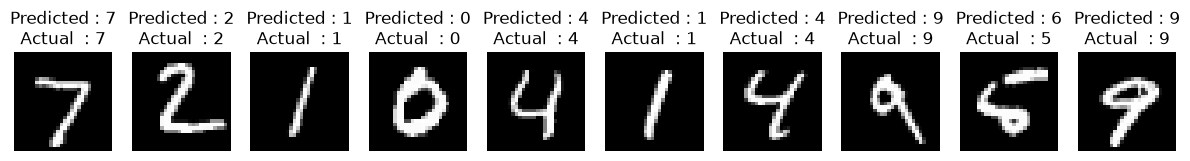

In [18]:
fig,axes = plt.subplots(1,10,figsize=(15,2))
for i,ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28,28),cmap='gray')
    ax.set_title(f"Predicted : {y_pred[i]}\nActual  : {y_test[i]}")
    ax.axis('off')
plt.show()

### 10.1 Confusion Matrix

With `y_pred` and `y_test` both as plain digit labels, we can see exactly
which digits get confused with which — e.g. 4s misread as 9s, a common
MNIST error pattern, far more informative than accuracy alone.

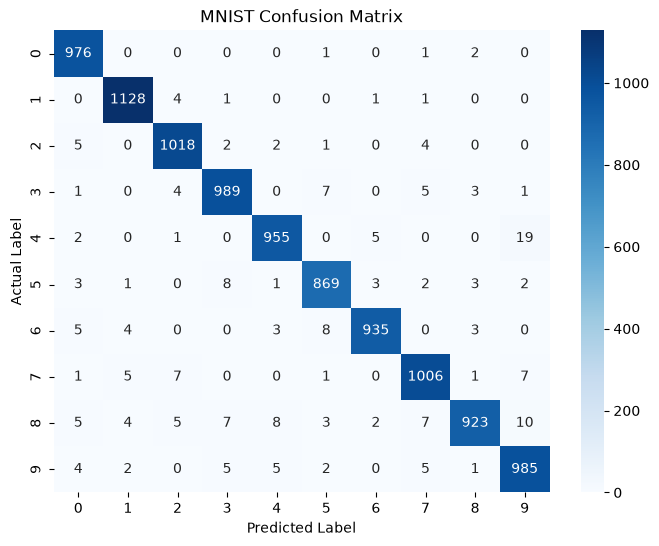

In [19]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MNIST Confusion Matrix")
plt.show()

### 10.2 Visualize Misclassified Digits

The most valuable diagnostic step — actually *looking* at what the model
got wrong. Some errors will be genuinely ambiguous handwriting (model isn't
"wrong," the digit is just messy); others may reveal a real pattern worth
investigating.

In [20]:
wrong_indices = np.where(y_pred != y_test)[0]
print("The Number of MissCalssified Classes are : ",len(wrong_indices))

The Number of MissCalssified Classes are :  216


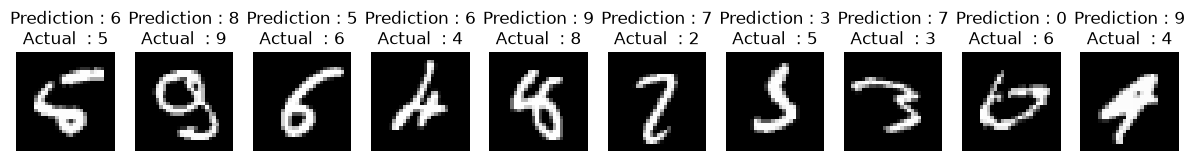

In [21]:
fig,axes = plt.subplots(1,10,figsize=(15,2))
for i,ax in enumerate(axes):
    index = wrong_indices[i]
    ax.imshow(X_test[index].reshape(28,28),cmap='gray')
    ax.set_title(f"Prediction : {y_pred[index]}\nActual  : {y_test[index]}")
    ax.axis('off')
plt.show()

### 10.3 Which Class/Label Most Confuses our Model

In [22]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag,0)
index = np.unravel_index(np.argmax(cm_no_diag),cm_no_diag.shape)
actual = index[0]
predicted = index[1]
count = cm_no_diag[index]
print("Most Common Confusion :- ")
print("Actual : ",actual)
print("Predicted : ",predicted)
print("Number of times : ",count)


Most Common Confusion :- 
Actual :  4
Predicted :  9
Number of times :  19


## 11. Save the Model

In [23]:
model.save("models/mnist_digit_model.keras")

### 11.1 Check Saving our Model Properly 

By loading it and try the same prediction on the first testing example

In [24]:
loaded_model = tf.keras.models.load_model("models/mnist_digit_model.keras")

In [25]:
logit = loaded_model.predict(X_test[0].reshape(1,784))
probablity = tf.nn.softmax(logit)
y_p = np.argmax(probablity)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [26]:
print(f"The Z values of the first test example : ")
print(logit)
print(f"The a(Z) values of the first test example : ")
print(probablity)
print(f"The class with the max porbability of the first test example : ")
print(y_p)
print(f"The true label of the first test example : ")
print(y_test[0])

The Z values of the first test example : 
[[-11.648643   -2.5058358  -1.7470925   3.1065166 -10.881305   -3.290433
  -20.499025   17.443577   -7.013103   -0.4462351]]
The a(Z) values of the first test example : 
tf.Tensor(
[[2.3195782e-13 2.1681015e-09 4.6301780e-09 5.9359979e-07 4.9964275e-13
  9.8931396e-10 3.3245755e-17 9.9999940e-01 2.3911038e-11 1.7004069e-08]], shape=(1, 10), dtype=float32)
The class with the max porbability of the first test example : 
7
The true label of the first test example : 
7


# Conclusion

The neural network achieved approximately 97.7% accuracy on the MNIST test set.

The model successfully learned to classify handwritten digits from 0 to 9. The confusion matrix and misclassified images provided additional insight into the types of digits the model sometimes confuses.

The trained model was saved in Keras format and can now be reused for deployment.

### Next Steps

- Move the trained model into a structured PyCharm project
- Build a prediction script
- Create a Streamlit interface
- Allow users to upload or draw handwritten digits
- Display the predicted digit and prediction confidence